## Replicando o que foi feito no primeiro e segundo arquivo dessa analise

In [1]:
# Importando o pandas
import pandas as pd

In [2]:
# Visualizando a base de treino
treino = pd.read_csv('train.csv')
treino.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [3]:
# Visualizando a base de teste
teste = pd.read_csv('test.csv')
teste.head(3)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q


In [4]:
# Eliminando as colunas com elevada cardinalidade
treino = treino.drop(['Name','Ticket','Cabin'],axis=1)
teste = teste.drop(['Name','Ticket','Cabin'],axis=1)

In [5]:
# Usando a média para substituir valores nulos na coluna de idade
treino.loc[treino.Age.isnull(),'Age'] = treino.Age.mean()
teste.loc[teste.Age.isnull(),'Age'] = teste.Age.mean()

In [6]:
# Tratando a coluna Embarked da base de treino usando a moda 
treino.loc[treino.Embarked.isnull(),'Embarked'] = treino.Embarked.mode()[0]

In [7]:
# E também a coluna Fare da base de teste usando a média
teste.loc[teste.Fare.isnull(),'Fare'] = teste.Fare.mean()

In [8]:
# Usando uma lambda function para tratar a coluna "Sex"
treino['MaleCheck'] = treino.Sex.apply(lambda x: 1 if x == 'male' else 0)
teste['MaleCheck'] = teste.Sex.apply(lambda x: 1 if x == 'male' else 0)

In [9]:
# Criando o encoder e fazendo o fit com os dados
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore',dtype='int32')
ohe = ohe.fit(treino[['Embarked']])

In [10]:
# Atualizando a base de treino com os novos valores
ohe_df = pd.DataFrame(ohe.transform(treino[['Embarked']]).toarray(),columns=ohe.get_feature_names_out())
treino = pd.concat([treino,ohe_df],axis=1)

In [11]:
# e a base de teste
ohe_df = pd.DataFrame(ohe.transform(teste[['Embarked']]).toarray(),columns=ohe.get_feature_names_out())
teste = pd.concat([teste,ohe_df],axis=1)

In [12]:
# Podemos então apagar essas duas colunas que já tratamos
treino = treino.drop(['Sex','Embarked'],axis=1)
teste = teste.drop(['Sex','Embarked'],axis=1)

In [13]:
# Visualizando a base de treino
treino.head(3)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,MaleCheck,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,1,0,0,1
1,2,1,1,38.0,1,0,71.2833,0,1,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,0,1


## Usando os modelos nessa nova base
<a id="minha_secao"></a>

In [157]:
# Importando o train_test_split
from sklearn.model_selection import train_test_split

In [158]:
# Separando a base de treino em X e y
X = treino.drop(['PassengerId', 'Survived'], axis=1)
y = treino.Survived

In [159]:
# Separando em treino e validaçõa
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.33, random_state=42)

### Arvore de classificação

In [160]:
# Fazendo a importação
from sklearn import tree

In [161]:
# Criando o classificador
clf_ac = tree.DecisionTreeClassifier(random_state=42)

In [162]:
# Fazendo o fit com os dados
clf_ac = clf_ac.fit(X_train, y_train)

In [163]:
# Fazendo a previsão
y_pred_ac = clf_ac.predict(X_val)

### KNeighborsClassifier

In [164]:
# Importando 
from sklearn.neighbors import KNeighborsClassifier

In [165]:
# Criando o classificador
clf_knn = KNeighborsClassifier(n_neighbors=3)

In [166]:
# Fazendo fit com os dados
clf_knn = clf_knn.fit(X_train, y_train)

In [167]:
# Fazendo a previsão
y_pred_knn = clf_knn.predict(X_val)

### Regressão Logistica

In [168]:
# Importando 
from sklearn.linear_model import LogisticRegression

In [169]:
# Criando o classificador
clf_r1 = LogisticRegression(random_state=42, max_iter=1000)

In [170]:
# Fazendo o fit com os dados
clf_r1 = clf_r1.fit(X_train, y_train)

In [171]:
# Fazendo a previsão
y_pred_r1 = clf_r1.predict(X_val)

## Avaliando modelos

### Acuracia

In [172]:
# Importando
from sklearn.metrics import accuracy_score

In [173]:
# Para a árvore 
as_ac = accuracy_score(y_val, y_pred_ac)
as_ac

0.7627118644067796

In [174]:
as_knn = accuracy_score(y_val, y_pred_knn)
as_knn

0.7864406779661017

In [175]:
as_r1 = accuracy_score(y_val, y_pred_r1)
as_r1

0.8101694915254237

### Matriz de Confusão

In [112]:
# Importando
from sklearn.metrics import confusion_matrix

In [113]:
# Para a árvore
confusion_matrix(y_val, y_pred_ac)

array([[135,  40],
       [ 38,  82]])

In [114]:
# Para o knn 
confusion_matrix(y_val, y_pred_knn)

array([[153,  22],
       [ 41,  79]])

In [115]:
# Para a regressão logistica
confusion_matrix(y_val, y_pred_r1)

array([[151,  24],
       [ 33,  87]])

### Visualizando os valores em um DataFrame

In [37]:
# Criando o DataFrame
as_df = pd.DataFrame({
    'modelos': ['arvore', 'knn', 'reg. log'],
    'inicial': [as_ac, as_knn, as_r1]
})
as_df

,modelos,inicial
0,arvore,0.749153
1,knn,0.715254
2,reg. log,0.816949


In [111]:
as_df['pessoas'] = [as_ac, as_knn, as_r1]
as_df

,modelos,inicial,escala,pessoas
0,arvore,0.749153,0.749153,0.735593
1,knn,0.715254,0.800000,0.786441
2,reg. log,0.816949,0.816949,0.806780


## Analisando a escala dos dados

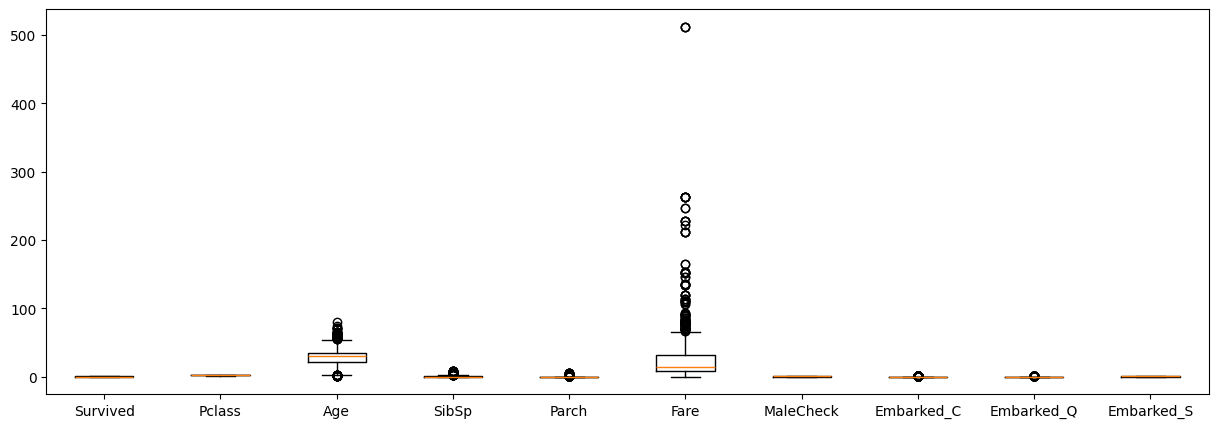

In [38]:
# Visualizando a escala dos dados
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15,5))

ax.boxplot(treino.iloc[:,1:11])
ax.set_xticks(range(1, treino.iloc[:,1:11].shape[1]+1), treino.iloc[:,1:11].columns)

In [39]:
# Importando o RobustScaler
from sklearn.preprocessing import RobustScaler

In [40]:
# Criando o scaler
transformer = RobustScaler().fit(treino[['Age', 'Fare']])

In [41]:
# Fazendo a transformação dos dados
treino[['Age', 'Fare']] = transformer.transform(treino[['Age', 'Fare']])

In [42]:
# Fazendo o mesmo para a base de teste
transformer = RobustScaler().fit(teste[['Age', 'Fare']])
teste[['Age', 'Fare']] = transformer.transform(teste[['Age', 'Fare']])

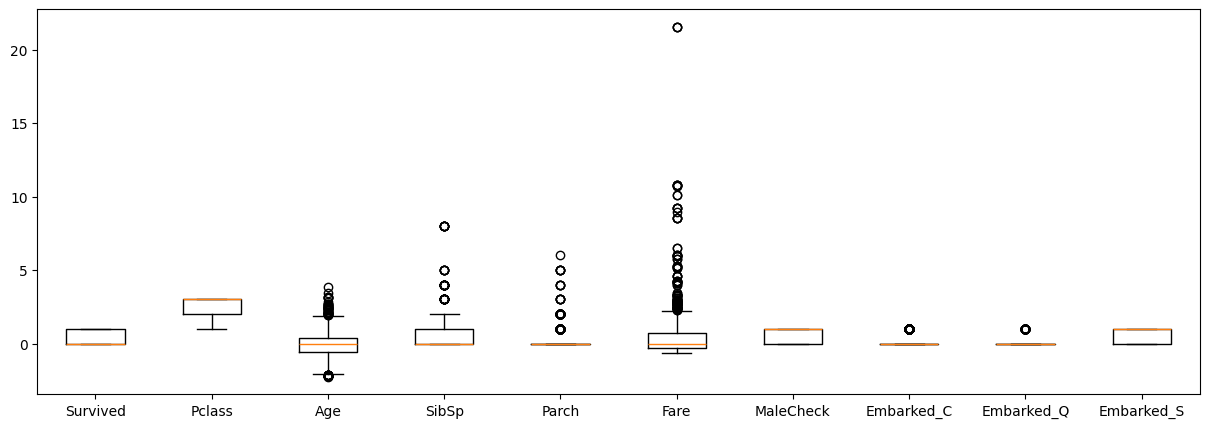

In [43]:
# Visualizando novamente os dados
fig, ax = plt.subplots(figsize=(15,5))

ax.boxplot(treino.iloc[:,1:11])
ax.set_xticks(range(1, treino.iloc[:,1:11].shape[1]+1), treino.iloc[:,1:11].columns)

plt.show()

**Observação:** Antes de criar o DataFrame com a escala dos dados ajutados, precisa reexecutar os modelos com a base nova 

In [72]:
# Adicionando novas colunas no DataFrame
as_df['escala'] = [as_ac, as_knn, as_r1]

In [73]:
# Visulizando
as_df

,modelos,inicial,escala
0,arvore,0.749153,0.749153
1,knn,0.715254,0.800000
2,reg. log,0.816949,0.816949


## Entendendo as colunas SibSp e Parch

- Agora podemos entender as colunas **SibSp** e **Parch**:
  - **SibSp**: Nº de irmãos/cônjuges a bordo do Titanic
  - **Parch**: Nº de pais/filhos a bordo do Titanic

- Podemos verificar quantas pessoas sobreviveram em cada um dos valores dessa coluna

In [74]:
# Verificando a sobrevivência para SibSp
SibSp_df = treino.groupby('SibSp')['Survived'].agg(['sum', 'count', 'mean']).reset_index()
SibSp_df.columns = ['SibSp', 'sobrev', 'total', 'tx_sobrev']
SibSp_df

,SibSp,sobrev,total,tx_sobrev
0,0,210,608,0.345395
1,1,112,209,0.535885
2,2,13,28,0.464286
3,3,4,16,0.250000
4,4,3,18,0.166667
5,5,0,5,0.000000
6,8,0,7,0.000000


In [75]:
# Verificando a sobrevivência para Parch
Parch_df = treino.groupby('Parch')['Survived'].agg(['sum', 'count', 'mean']).reset_index()
Parch_df.columns = ['Parch', 'sobrev', 'total', 'tx_sobrev']
Parch_df

,Parch,sobrev,total,tx_sobrev
0,0,233,678,0.343658
1,1,65,118,0.550847
2,2,40,80,0.500000
3,3,3,5,0.600000
4,4,0,4,0.000000
5,5,1,5,0.200000
6,6,0,1,0.000000


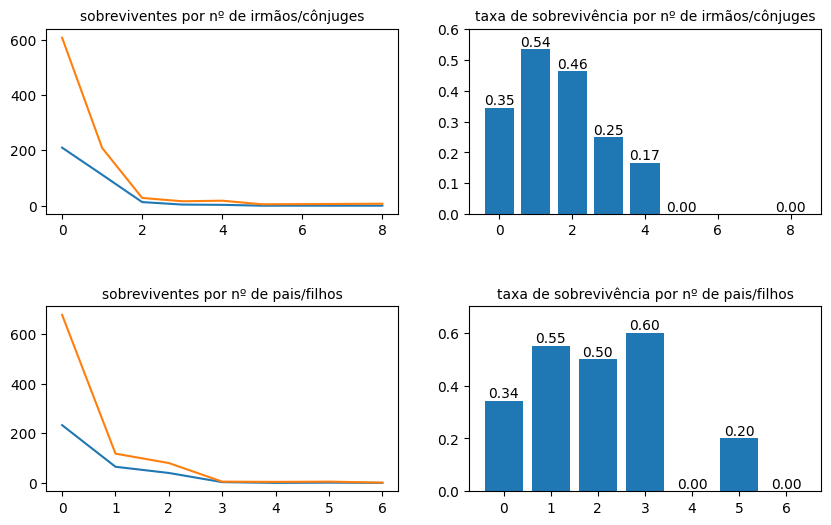

In [76]:
# Visualizando essas informações graficamente
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10,6))

ax[0,0].plot(SibSp_df.SibSp, SibSp_df.sobrev)
ax[0,0].plot(SibSp_df.SibSp, SibSp_df.total)
ax[0,0].set_title('sobreviventes por nº de irmãos/cônjuges', fontsize=10)

labels1 = ax[0,1].bar(SibSp_df.SibSp, SibSp_df.tx_sobrev)
ax[0,1].bar_label(labels1, fmt="%.02f")
ax[0,1].set_ylim(0,0.6)
ax[0,1].set_title('taxa de sobrevivência por nº de irmãos/cônjuges', fontsize=10)

ax[1,0].plot(Parch_df.Parch, Parch_df.sobrev)
ax[1,0].plot(Parch_df.Parch, Parch_df.total)
ax[1,0].set_title('sobreviventes por nº de pais/filhos', fontsize=10)

labels2 = ax[1,1].bar(Parch_df.Parch, Parch_df.tx_sobrev)
ax[1,1].bar_label(labels2, fmt="%.02f")
ax[1,1].set_ylim(0,0.7)
ax[1,1].set_title('taxa de sobrevivência por nº de pais/filhos', fontsize=10)

plt.subplots_adjust(hspace=0.5)

plt.show()

- **Passageiros viajando sozinho tiveram um menor percentual de sobrevivência**
    - Podemos criar uma nova coluna identificando se o passageiro está viajando sozinho 

In [78]:
# Criando uma função para verificar se dois valores são vazios
def sozinho(a,b):
    if(a==0 and b==0):
        return 1
    else:
        return 0

In [81]:
# Aplicando essa função na base de treino
treino['Sozinho'] = treino.apply(lambda x: sozinho(x.SibSp, x.Parch), axis=1)

In [82]:
# Verificando os valores nessa coluna
treino.groupby('Sozinho')[['SibSp', 'Parch']].mean()

,SibSp,Parch
Sozinho,,
0,1.316384,0.960452
1,0.000000,0.000000


In [83]:
# Fazendo o mesmo para base de teste
teste['Sozinho'] = teste.apply(lambda x: sozinho(x.SibSp, x.Parch), axis=1)

**Observação:** Criando uma nova coluna sendo o total de familiares a bordo

In [84]:
# Criando para a base de treino
treino['Familiares'] = treino.SibSp + treino.Parch

In [85]:
# Fazendo o mesmo para base de teste
teste['Familiares'] = teste.SibSp + teste.Parch

In [89]:
# Verificando a taxa de sobrevivencia para familiares
Familiares_df = treino.groupby('Familiares')['Survived'].agg(['sum', 'count', 'mean']).reset_index()
Familiares_df.columns = ['Familiares', 'sobrev', 'total', 'tx_sobrev']
Familiares_df

,Familiares,sobrev,total,tx_sobrev
0,0,163,537,0.303538
1,1,89,161,0.552795
2,2,59,102,0.578431
3,3,21,29,0.724138
4,4,3,15,0.200000
5,5,3,22,0.136364
6,6,4,12,0.333333
7,7,0,6,0.000000
8,10,0,7,0.000000


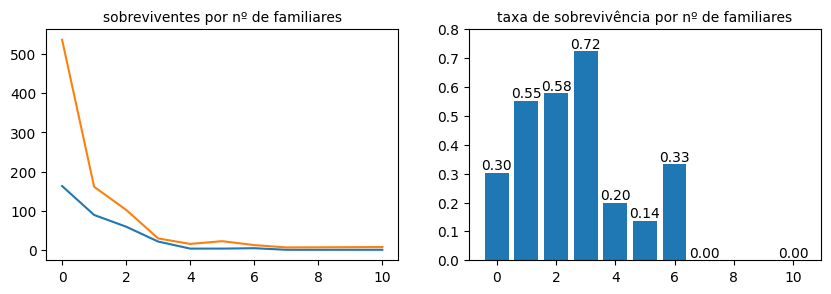

In [90]:
# Visualizando a informação de familiares
fig, ax = plt.subplots(ncols=2, figsize=(10,3))

ax[0].plot(Familiares_df.Familiares, Familiares_df.sobrev)
ax[0].plot(Familiares_df.Familiares, Familiares_df.total)
ax[0].set_title('sobreviventes por nº de familiares', fontsize=10)

labels1 = ax[1].bar(Familiares_df.Familiares, Familiares_df.tx_sobrev)
ax[1].bar_label(labels1, fmt="%.02f")
ax[1].set_ylim(0,0.8)
ax[1].set_title('taxa de sobrevivência por nº de familiares', fontsize=10)

plt.show()

**Observação:** Reexecuta o modelo com a nova base de dados

## Selecionando os melhores recursos

In [116]:
# Visualizando a base
treino.head(3)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,MaleCheck,Embarked_C,Embarked_Q,Embarked_S,Sozinho,Familiares
0,1,0,3,-0.592240,1,0,-0.312011,1,0,0,1,0,1
1,2,1,1,0.638529,1,0,2.461242,0,1,0,0,0,1
2,3,1,3,-0.284548,0,0,-0.282777,0,0,0,1,1,0


In [117]:
# Analisando a correlaçao entre as variaveis
treino.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,MaleCheck,Embarked_C,Embarked_Q,Embarked_S,Sozinho,Familiares
PassengerId,1.000000,-0.005007,-0.035144,0.033207,-0.057527,-0.001652,0.012658,0.042939,-0.001205,-0.033606,0.022204,0.057462,-0.040143
Survived,-0.005007,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307,-0.543351,0.168240,0.003650,-0.149683,-0.203367,0.016639
Pclass,-0.035144,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500,0.131900,-0.243292,0.221009,0.074053,0.135207,0.065997
Age,0.033207,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566,0.084153,0.032024,-0.013855,-0.019336,0.179775,-0.248512
SibSp,-0.057527,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651,-0.114631,-0.059528,-0.026354,0.068734,-0.584471,0.890712
Parch,-0.001652,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225,-0.245489,-0.011069,-0.081228,0.060814,-0.583398,0.783111
Fare,0.012658,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000,-0.182333,0.269335,-0.117216,-0.162184,-0.271832,0.217138
MaleCheck,0.042939,-0.543351,0.131900,0.084153,-0.114631,-0.245489,-0.182333,1.000000,-0.082853,-0.074115,0.119224,0.303646,-0.200988
Embarked_C,-0.001205,0.168240,-0.243292,0.032024,-0.059528,-0.011069,0.269335,-0.082853,1.000000,-0.148258,-0.782742,-0.095298,-0.046215
Embarked_Q,-0.033606,0.003650,0.221009,-0.013855,-0.026354,-0.081228,-0.117216,-0.074115,-0.148258,1.000000,-0.499421,0.086464,-0.058592


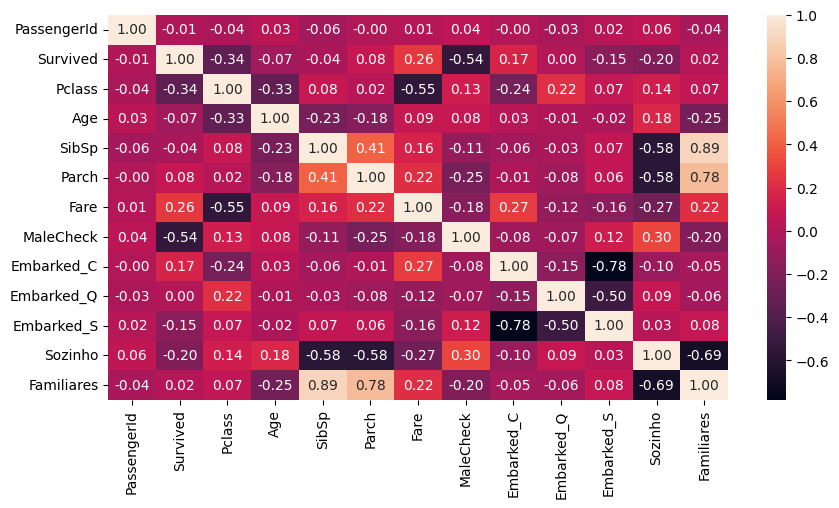

In [120]:
# Tornando a correlação visual
import seaborn as sns

fig, ax = plt.subplots(figsize=(10,5))

sns.heatmap(treino.corr(), annot=True, fmt=".2f")

plt.show()

**Observação:** Analisando a relação entre Pclass e Fare

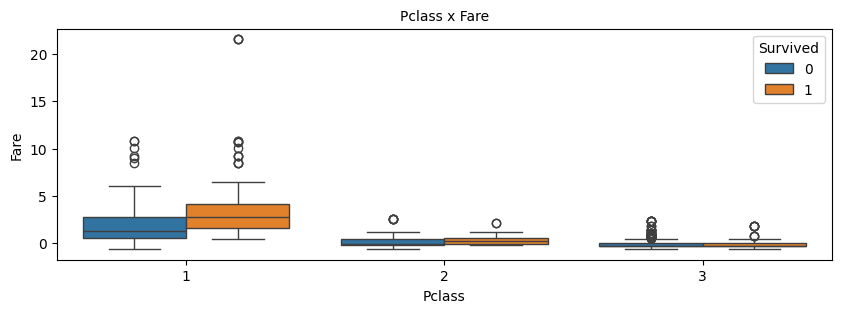

In [121]:
# Visualizando a relação entre essas variáveis
fig, ax = plt.subplots(figsize=(10,3))

sns.boxplot(data=treino, x='Pclass', y='Fare', hue='Survived')
ax.set_title('Pclass x Fare', fontsize=10)

plt.show()

In [122]:
# Verificando a taxa de sobrevivência em cada uma das classes
treino.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

## Analisando as colunas de embarque

In [134]:
# Importando novamente as bases para "Recuperar" a coluna de embarque
treino2 = pd.read_csv('train.csv')
teste2 = pd.read_csv('test.csv')

treino2.head(3)



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [126]:
# Como temos valores vazios, podemos fazer novamente o tratamento de dados
treino2['Embarked'] = treino2['Embarked'].fillna('S')

### Colocando o porto em ordem de embarque (S -> C -> Q)
**Como dito no artigo https://pt.wikipedia.org/wiki/RMS_Titanic**

In [127]:
# Importando OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder

In [130]:
# Criando o encoder
categorias = ['S', 'C', 'Q']

enc = OrdinalEncoder(categories=[categorias], dtype='int32')

In [131]:
# faznedo o fit com os dados
enc = enc.fit(treino2[['Embarked']])

In [133]:
# Adicionando essa coluna na base de treino original
treino['Embarked'] = enc.transform(treino2[['Embarked']])

In [135]:
# Fit com dados de teste
enc = enc.fit(teste2[['Embarked']])

In [136]:
# Adicionando na base de teste original
teste['Embarked'] = enc.transform(teste2[['Embarked']])

In [152]:
# Eliminando as colunas desnecessarias
treino = treino.drop(['Embarked_C', 'Embarked_Q', 'Embarked_S'], axis=1)
teste = teste.drop(['Embarked_C', 'Embarked_Q', 'Embarked_S'], axis=1)

KeyError: "['Embarked_C', 'Embarked_Q', 'Embarked_S'] not found in axis"

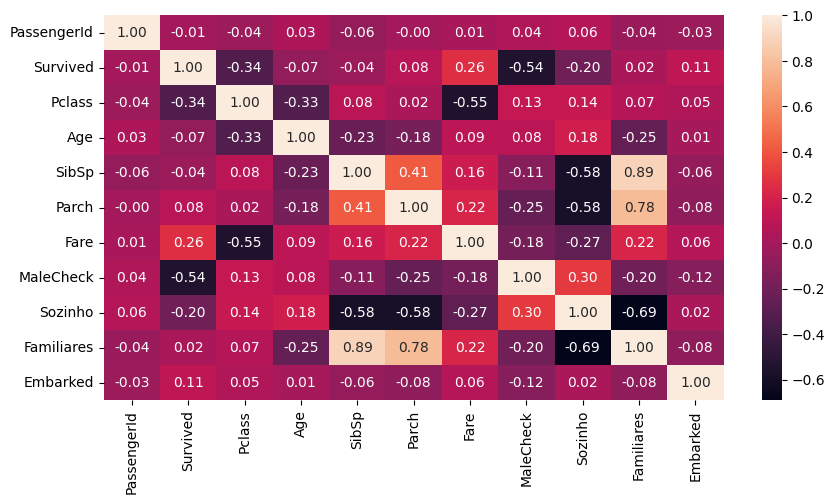

In [138]:
# Visualizando novamente a correlação
fig, ax = plt.subplots(figsize=(10,5))

sns.heatmap(treino.corr(), annot=True, fmt=".2f")

plt.show()

## Analisando a coluna familia
- Verificando a importância de cada uma dessas colunas usando regressão logistica e arvore de classificação

In [145]:
# Separando X e Y
x = treino.drop(['PassengerId', 'Survived'], axis=1)
y = treino.Survived

In [146]:
# Usando a regressão logística nos dados
clf_r1 = LogisticRegression(random_state=42, max_iter=1000).fit(X,y)

In [147]:
# Verificando a importância
clf_r1.coef_[0]

array([-1.0219525 , -0.49279087, -0.26267919,  0.01455456,  0.04124139,
       -2.54382376,  0.08886579,  0.15898288, -0.23590163, -0.71137158,
       -0.24812462])

In [148]:
# Usando a arvore de classificacao
clf_ac = tree.DecisionTreeClassifier(random_state=42).fit(X,y)

In [149]:
# Verificando a importancia
clf_ac.feature_importances_

array([0.10569248, 0.25443631, 0.03525541, 0.00966112, 0.23254069,
       0.30933519, 0.00669015, 0.00372914, 0.00547207, 0.00401541,
       0.03317203])

In [150]:
# Criando um DataFrame
imp = pd.DataFrame({
    'colunas': X.columns,
    'red. log': clf_r1.coef_[0],
    'arvore': clf_ac.feature_importances_
})
imp

,colunas,red. log,arvore
0,Pclass,-1.021953,0.105692
1,Age,-0.492791,0.254436
2,SibSp,-0.262679,0.035255
3,Parch,0.014555,0.009661
4,Fare,0.041241,0.232541
5,MaleCheck,-2.543824,0.309335
6,Embarked_C,0.088866,0.006690
7,Embarked_Q,0.158983,0.003729
8,Embarked_S,-0.235902,0.005472
9,Sozinho,-0.711372,0.004015


In [155]:
# Mantendo apenas as colunas mais relevanetes
treino = treino.drop(['SibSp', 'Parch'], axis=1)
teste = teste.drop(['SibSp', 'Parch'], axis=1)

KeyError: "['SibSp', 'Parch'] not found in axis"

In [156]:
# Mantendo as colunas mais importantes na base de teste
teste = teste.drop(['SibSp', 'Parch'], axis=1)

**Observação:** Reexecuta os modelos com a nova base de dados para analisar a acuracia

In [176]:
# Adicionando nova coluna no DF
as_df['colunas'] = [as_ac, as_knn, as_r1]

In [177]:
# Visualizando 
as_df

,modelos,inicial,escala,pessoas,colunas
0,arvore,0.749153,0.749153,0.735593,0.762712
1,knn,0.715254,0.800000,0.786441,0.786441
2,reg. log,0.816949,0.816949,0.806780,0.810169


## Fazendo a previsão na base de teste

In [178]:
# Visualizando o X_train
X_train.head(3)

,Pclass,Age,Fare,MaleCheck,Sozinho,Familiares,Embarked
6,1,1.869299,1.620136,1,1,0,0
718,3,0.000000,0.045293,1,1,0,2
685,2,-0.361471,1.174771,1,0,3,1


In [179]:
# Visualizando a base de teste
teste.head(3)

,PassengerId,Pclass,Age,Fare,MaleCheck,Sozinho,Familiares,Embarked
0,892,3,0.331562,-0.280670,1,1,0,2
1,893,3,1.311954,-0.315800,0,0,1,0
2,894,2,2.488424,-0.201943,1,1,0,2


In [180]:
# Para a base de teste ser igual a de treino, precisamos eliminar a coluna de id
X_teste = teste.drop('PassengerId', axis=1)

In [181]:
# Usando a regressão logistica na base de teste
y_pred = clf_r1.predict(X_teste)

In [182]:
# Criando uma nova coluna com a previsão na base de teste
teste['Survived'] = y_pred

In [183]:
# Selecionando apenas a coluna de Id e Survived para fazer o envio
base_envio = teste[['PassengerId', 'Survived']]

In [184]:
# Exportando para um csv
base_envio.to_csv('resultados_completos.csv', index=False)